# Part 7: Multiple Regression {-}

In this part, we will extend from the simple linear regression
model to **multiple regression**.

These models
comprise the familiar linear models that take the form
\begin{equation*}
   Y = \beta_0 + \sum_{j=1}^p \beta_j x_j + \epsilon
\end{equation*}

where $\epsilon$ are assumed to be uncorrelated
with mean zero and variance $\sigma^2$.

Assuming that
the $\epsilon$ are normally distributed brings additional
nice properties, but is generally not essential.

We will go through the fundamental steps of fitting such a model
via an example.

\newpage

## Example: Factor Models {-}

References to the "beta" for a stock derive from the
slope of the regression line fit to a scatter plot where
excess return for that equity is the response, and excess market
return is the predictor.
Models of this form are an important component
of **Capital Asset Pricing Model (CAPM)**.

The term **Factor Model** is used to indicate any
linear model for excess return on an equity. The predictors
in the model are the **factors**.

Quoting Ruppert, examples of factors include

1. excess returns on the market portfolio beyond the risk-free return
2. growth rate of the GDP;
3. interest rate on short term Treasury bills or changes in this rate;
4. inflation rate or changes in this rate;
5. interest rate spreads;
6. return on some portfolio of stocks;
7. the difference between the returns on two portfolios.


The CAPM only includes the factor for excess market return.

The **Fama-French Three Factor Model** adds two
factors.

The first is **small minus big (SMB)**, the difference
in returns between portfolios of small and large stocks.

The second is **high minus low (HML)**, the difference
in returns between portfolios of high and low book-to-market
stocks.


\newpage

Kenneth French maintains a web site with data on the three factors

[http://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html](http://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html)

This Python function allows for easy access to the
daily factor data.

In [15]:
import pandas_datareader.data as web
import datetime, re, copy

def getFamaFrench(from_date, to_date):
    
    three_fac = web.DataReader(\
        "F-F_Research_Data_Factors_daily",
        "famafrench")
    f = copy.copy(three_fac[0])
    f.rename( columns={c:re.sub(r'[0-9\-\s]','',c)\
        for c in f.columns}, inplace=True)
    
    datetime.datetime.strptime(from_date, "%Y-%m-%d")
    datetime.datetime.strptime(to_date, "%Y-%m-%d")
    
    out = f[(f.index > datetime.datetime.strptime\
        (from_date, "%Y-%m-%d")) &
            (f.index < datetime.datetime.strptime\
        (to_date, "%Y-%m-%d"))]
    
    return out

An example, and the first few rows of the data returned are as follows. (These 
factors are periodically revised, and hence the exact
numbers may be different at the present time. This will affect the
subsequent analysis, as well.)

In [16]:
ffhold = getFamaFrench(from_date="2016-1-1", 
                to_date="2016-6-30")

ffhold.iloc[0:10,]

,MktRF,SMB,HML,RF
Date,,,,
2016-01-04,-1.59,-0.84,0.53,0.0
2016-01-05,0.12,-0.22,0.02,0.0
2016-01-06,-1.35,-0.12,-0.01,0.0
2016-01-07,-2.44,-0.28,0.08,0.0
2016-01-08,-1.11,-0.48,-0.03,0.0
2016-01-11,-0.06,-0.64,0.34,0.0
2016-01-12,0.72,-0.40,-0.80,0.0
2016-01-13,-2.67,-0.70,0.79,0.0
2016-01-14,1.65,-0.01,-0.39,0.0


\newpage

Let's get the data for PNC for the same time period. The Python package `yfinance` makes this simple.

In [17]:
import yfinance as yf

PNC = yf.download("PNC", "2016-01-01",
        "2016-06-30")

[*********************100%***********************]  1 of 1 downloaded


Now find the excess returns for PNC. Note that the Fama-French
data file includes the risk free rate, with name `RF`:

In [18]:
ffhold['PNCexret'] = \
 100*PNC['Adj Close'].pct_change() - ffhold['RF']

The first row does not have a return, so remove it.

In [19]:
ffhold = ffhold[1:]

\newpage

The three factor model we fit is
\begin{equation*}
   \mbox{PNC.Ex.Ret.} = \beta_0 + \beta_1 \:\mbox{Mkt.Ex.Ret.}
   + \beta_2 \:\mbox{SMB} + \beta_3 \:\mbox{HML} + \epsilon
\end{equation*}

A Python command for fitting a linear regression is `ols` in package `statsmodels`.

In [20]:
import statsmodels.api as sm

ff3modPNC = sm.OLS.from_formula\
  (formula="PNCexret ~ MktRF + SMB + HML",
     data=ffhold).fit()

\newpage

The key information from the fit of the model is stored in the
object `ff3modPNC`. For example, to see the parameter estimates and their standard errors for the estimators:

In [21]:
ff3modPNC.params

Intercept   -0.151925
MktRF        1.215999
SMB         -0.011464
HML          0.798166
dtype: float64

In [22]:
ff3modPNC.bse

Intercept    0.070081
MktRF        0.070531
SMB          0.139419
HML          0.120677
dtype: float64

You can obtain the residuals from `ff3modPNC.resid` and the fitted values from `ff3modPNC.fittedvalues`.

Look at `ff3modPNC.summary()` for a more complete summary.

\newpage

## Diagnostic Plots {-}

The figure above shows four scatter plots constructed by
Francis Anscombe for a 1973 research article. These are
called **Anscombe's Quartet**. This is, in part, based on https://seaborn.pydata.org/examples/anscombes_quartet.html.

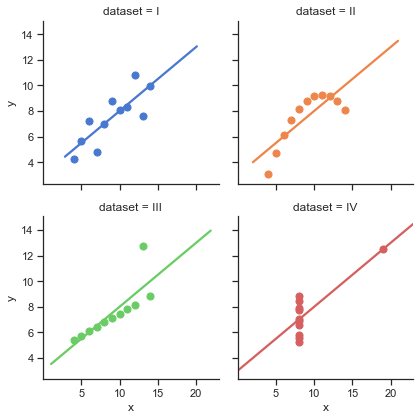

In [23]:
import seaborn as sns
sns.set(style="ticks")

ansdf = sns.load_dataset("anscombe")

hold = sns.lmplot(x="x", y="y", col="dataset", 
        hue="dataset", data=ansdf, col_wrap=2,
        ci=None, palette="muted", height=3,
        scatter_kws={"s": 50, "alpha": 1})

\newpage

**Exercise:** Find the sample mean and
standard deviation for both $x$ and $y$ in all four cases, to find the correlation between $x$ and $y$ in each case, and then use that to find the slope of the regression line for each.

\answerlines{3}

**Exercise:** This can be taken a step further: We could find that the residual sum of squares in all four cases is exactly the same. What does this imply about the inference for $\beta_1$ in all four cases?

\answerlines{3}

**Exercise:** What is the message we take away from this example?

\answerlines{8}

\newpage

A very useful diagnostic plot is that of the **residuals versus
the fitted values**. There are a wide range of models for which this
is an invaluable tool.

**Exercise:** If the assumptions of the model are correct,
what should we see in the plot of residuals versus fitted values?

\answerlines{7}

**Exercise:** Use the code below to explore the plot of residuals versus fitted values in the case of Anscombe's Quartet. Comment on the results.

\answerlines{10}

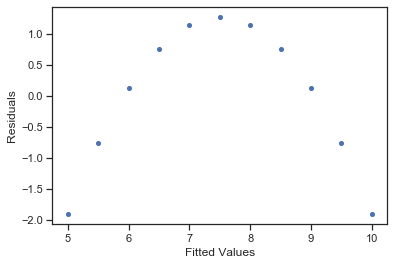

In [24]:
ansgrp = ansdf.groupby(ansdf.dataset)
onegrp = ansgrp.get_group("II")

ansfit = sm.OLS.from_formula\
  (formula="y~x", data=onegrp).fit()

import matplotlib.pyplot as plt

plt.scatter(ansfit.fittedvalues,
    ansfit.resid, s=16)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

\newpage

**Exercise:** Your colleague says, "I found the correlation
between the residuals and fitted values to be equal to zero, so there is 
clearly no relationship between the residuals and fitted values. 
So, the model must be fine." Do you agree with this logic?

\answerlines{10}

The residuals are also often plotted against each of the predictors. Our assumption is that the irreducible error is "random scatter" around the regression line/plane. If this assumption is true, there should be no remaining pattern evident in these plots.

\newpage

## The Normal Probability Plot {-}

We have already mentioned that when the irreducible errors can be assumed to be iid normal, then there are additional appealing results that can be stated:

1. The least squares estimator can be justified as being the maximum likelihood estimators.

2. The least squares estimators are exactly normal.

3. The least squares estimators, when appropriately scaled, have a $t$-distribution, which can be used to construct confidence intervals and hypothesis tests.

Overall, however, the value of this assumption is not that great. First, least squares can be motivated even if it does not lead to the MLE. Second, there are versions of the central limit theorem that state that, assuming the errors are independent (and some regularity conditions), the least squares estimator will be approximately normal for "large" $n$.

\newpage

Still, it can be useful to assess the normality of the residuals, as a means of assessing the normality of the irreducible error. The standard tool for doing this is the **normal probability plot**, which is a particular version of a **quantile-quantile plot**, or **QQ plot**.

In a QQ plot, one compares the sorted sample values versus the corresponding percentiles of the distribution being tested. More specifically, the $i^{th}$ order statistic is plotted versus the $100(i/(n+1)$ percentile of the distribution, for $i =1,2,\ldots, n$.
If the sample was drawn from that distribution, then the plot should show (approximately) a 45-degree line.

This may require the estimation of parameters of the distribution; if so, then use the best estimates available (e.g., MLE). Fortunately, in the normal case, this is unnecessary because a linear transformation of any normal is also normal. Hence, comparison with the standard normal is sufficient.

\newpage

In Python, this plot can be constructed using `qqplot()` found in `statsmodels`. Note the use of the `Fit` argument to force Python to compare with the best fitting distribution within the specified family.
(One can obtain fitted parameters using the `fit()` method.)

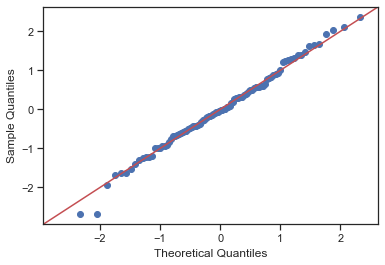

In [25]:
from statsmodels.graphics.gofplots import qqplot
import scipy.stats.distributions as spdists

x = spdists.t.rvs(30,size=100)
theodist = spdists.norm

qqplot(x, dist=theodist, line="45", fit=True)
plt.show()

\newpage

**Exercise:** Use the above code to try different examples and explore the use of this tool.

\answerlines{8}

**Exercise:** Explain why checking the normal probability plot of the residuals may be a good idea.

\answerlines{10}

\newpage

Let's now return to our PNC example.
The figure below shows three diagnostic plots:

1. Plot of residuals versus fitted values.
2. Plot of residuals versus the predictors.
3. Normal probability plot of the residuals.

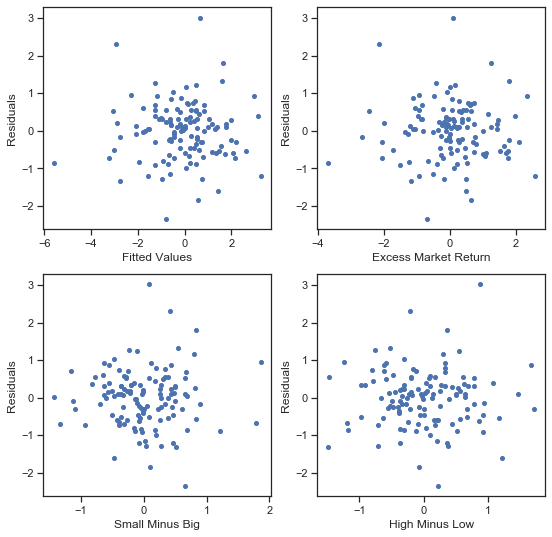

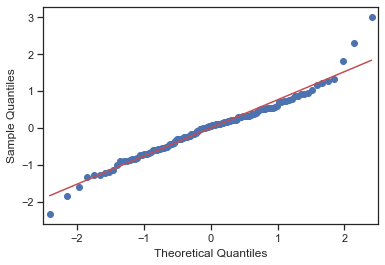

In [49]:

fig, axs = plt.subplots(2, 2,figsize=[9,9])

axs[0,0].scatter(ff3modPNC.fittedvalues,
    ff3modPNC.resid, s=16)
axs[0,0].set(xlabel="Fitted Values",ylabel="Residuals")

axs[0,1].scatter(ffhold.MktRF, ff3modPNC.resid, s=16)
axs[0,1].set(xlabel="Excess Market Return",ylabel="Residuals")

axs[1,0].scatter(ffhold.SMB, ff3modPNC.resid, s=16)
axs[1,0].set(xlabel="Small Minus Big",ylabel="Residuals")

axs[1,1].scatter(ffhold.HML, ff3modPNC.resid, s=16)
axs[1,1].set(xlabel="High Minus Low",ylabel="Residuals")

plt.show()

qqplot(ff3modPNC.resid, line='s')
plt.show()

**Exercise:** Comment on the quality of the fit.

\answerlines{9}

\newpage

## Linear Regression in Matrix Notation {-}

First, recall our simple linear regression model:
\begin{equation*}
   Y_i = \beta_0 + \beta_1 X_i + \epsilon_i, \:\:\:i=1,2,\ldots,n
\end{equation*}

We can rewrite this model in matrix notation by letting
\begin{equation*}
%\begin{array}{cc} 
{\bf Y} = \left[\begin{array}{c}Y_1\\Y_2\\ \vdots \\Y_n\end{array}\right]
\:\:\:\:\:\:
{\bf X} = \left[\begin{array}{cc}1&X_1\\1&X_2\\ \vdots & \vdots 
   \\1&X_n\end{array}\right] 
\:\:\:\:\:\:
\boldsymbol{\beta} = \left[\begin{array}{c}\beta_0\\\beta_1\end{array}\right]
\:\:\:\:\:\:
\boldsymbol{\epsilon} = \left[\begin{array}{c}\epsilon_1\\\epsilon_2\\ \vdots \\\epsilon_n\end{array}\right]
%\end{array}
\end{equation*}
and then noting that
\begin{equation*}
   {\bf Y} = {\bf X} \boldsymbol{\beta} + \boldsymbol{\epsilon}
\end{equation*}

When moving to multiple regression, the main change we must make is to add
columns to the matrix ${\bf X}$, commonly called the **design matrix**,
and add entries to $\boldsymbol{\beta}$:
\begin{equation*}
{\bf X} = \left[\begin{array}{ccccc}
1 & X_{11} & X_{12} & \cdots & X_{1,p}\\
1 & X_{21} & X_{22} & \cdots & X_{2,p}\\
\vdots & \vdots & \vdots & & \vdots \\
1 & X_{n1} & X_{n2} & \cdots & X_{n,p}\\
\end{array}\right] 
\:\:\:\:\:\:
\boldsymbol{\beta} = \left[\begin{array}{c}\beta_0\\\beta_1\\ \vdots\\ \beta_{p}\end{array}\right]
\end{equation*}

\newpage

One can show that the least
squares estimators (now a vector) are
\begin{equation*}
   \boldsymbol{\widehat \beta} = ({\bf X}^T{\bf X})^{-1} {\bf X}^T{\bf Y}.
\end{equation*}
and can now define the vector of fitted values and residuals
as
\begin{equation*}
{\bf \widehat {\bf Y}} = \left[\begin{array}{c}\widehat Y_1\\\widehat Y_2\\ \vdots \\\widehat Y_n\end{array}\right]
\:\:\:\:\:\mbox{and}\:\:\:\:\:
\boldsymbol{\widehat \epsilon} = \left[\begin{array}{c}\widehat \epsilon_1\\\widehat \epsilon_2\\ \vdots \\\widehat \epsilon_n\end{array}\right]
\end{equation*}
and it follows that 
\begin{equation*}
   \widehat {\bf Y} = {\bf X} \boldsymbol{\widehat \beta} \:\:\:\:\mbox{and}\:\:\: \boldsymbol{\widehat \epsilon}= {\bf Y} - {\bf \widehat Y}.
\end{equation*}

\newpage

## The Hat Matrix {-}

We note that we could write
\begin{equation*}
   \widehat {\bf Y} = {\bf X} \boldsymbol{\widehat \beta} = {\bf X} ({\bf X}^T{\bf X})^{-1} {\bf X}^T{\bf Y} = {\bf H} {\bf Y}
\end{equation*}
where
\begin{equation*}
   {\bf H} = {\bf X} ({\bf X}^T{\bf X})^{-1} {\bf X}^T
\end{equation*}
is called the **hat matrix** (because it puts a "hat" on ${\bf Y}$).

The diagonal entries of ${\bf H}$ are referred to as the **leverages**.

**Comment:** 
Mathematically, ${\bf H}$ is a **projection matrix**, as it "projects" the vector of observed
responses ${\bf Y}$ onto the space of all vectors which are linear combinations of the columns
of ${\bf X}$. In fact, we note that ${\bf H}$ is symmetric and **idempotent**, meaning that ${\bf H} {\bf H} = {\bf H}$.

**Exercise:** Show that ${\bf I} - {\bf H}$ is also symmetric and idempotent.

\answerlines{5}

\newpage
## Additional Results {-}

A range of important results can be proven:

1. The least squares estimator for $\boldsymbol{\beta}$ is $\boldsymbol{\widehat \beta} = ({\bf X}^T{\bf X})^{-1} {\bf X}^T {\bf Y}$.
2. The variance of $\boldsymbol{\widehat \beta}$ is $\sigma^2({\bf X}^T{\bf X})^{-1}$.
3. $\widehat {\bf Y} = {\bf X} \boldsymbol{\widehat \beta} = {\bf H} {\bf Y}$, where the (symmetric, idempotent) hat matrix ${\bf H}$ is defined as above.
4. $\boldsymbol{\widehat \epsilon} = {\bf Y} - {\bf \widehat Y} = ({\bf I} - {\bf H}) {\bf Y}$.
5. If $\boldsymbol{\epsilon}$ is assumed normal with mean zero and variance $\sigma^2\,{\bf I}$, the following hold:
    - $\boldsymbol{\widehat \beta}$ is the maximum likelihood estimator.
    - ${\bf Y}$ is multivariate normal with mean ${\bf X} \boldsymbol{\beta}$ and covariance $\sigma^2\,{\bf I}$.
    - $\boldsymbol{\widehat \beta}$ is multivariate normal with mean $\boldsymbol{\beta}$ and covariance $\sigma^2({\bf X}^T{\bf X})^{-1}$.
    - ${\bf \widehat Y}$ is multivariate normal with mean ${\bf X} \boldsymbol{\beta}$ and covariance $\sigma^2\,{\bf H}$.
    - $\boldsymbol{\widehat \epsilon}$ is multivariate normal with mean zero and covar. $\sigma^2({\bf I} - {\bf H})$.

\newpage

## Degrees of Freedom {-}

One key thing that does change when moving to multiple regression is the number of
**degrees of freedom** in the residual vector.

Recall that we had seen previously that with simple linear regression, it held that
\begin{equation*}
   \sum_i \widehat \epsilon_i = 0 \:\:\:\mbox{and}\:\:\: \sum_i \widehat \epsilon_i X_i = 0.
\end{equation*}
This result is one way of seeing why the residuals only have $n-2$ degrees of freedom in the
case of simple linear regression: There are two constraints placed on the vector of residuals.

But, these facts could be written more compactly using matrix notation: ${\bf X}^T \boldsymbol{\widehat \epsilon} = {\bf 0}$,
where ${\bf 0}$ is a vector consisting entirely of zeros.

In fact, this result extends to multiple regression: The vector of residuals $\boldsymbol{\widehat \epsilon}$ is
orthogonal to **every column** of ${\bf X}$, i.e., ${\bf X}^T \boldsymbol{\widehat \epsilon} = {\bf 0}$.

\newpage

**We now can state that there are $n-(p+1)$ degrees of freedom in the residuals**, and hence need to
update some of our previous results. (You will note that simple linear regression corresponds to
the case where $p=1$.) 

In particular:

1. The unbiased estimator of $\sigma^2$ is
\begin{equation*}
   \widehat \sigma^2 = {\rm RSS}\bigg/(n-p-1)
\end{equation*}
2. When the errors of i.i.d. normal, the statistic
\begin{equation*}
   \frac{\widehat \beta_i - \beta_i}{\widehat {\rm SE}(\widehat \beta_i)}
\end{equation*}
has the $t$-distribution with $n-p-1$ degrees of freedom. Hence, a 100$(1-\alpha)\%$ confidence interval for $\beta_i$ is formed as
\begin{equation*}
   \widehat \beta_i \pm t_{\alpha/2, n-p-1} \,\widehat {\rm SE}(\widehat \beta_i)
\end{equation*}
and hypothesis tests concerning $\beta_i$ should compare the test statistic
(the "t value") with the $t$-distribution with $n-p-1$ degrees of freedom.
3. For large $n$, we can appeal to the central limit theorem and construct an approximate 100$(1-\alpha)\%$ confidence interval for $\beta_i$ using
\begin{equation*}
   \widehat \beta_i \pm z_{\alpha/2} \,\widehat {\rm SE}(\widehat \beta_i)
\end{equation*}

\newpage

## Basic Variable Selection {-}

The process of **variable selection** in regression consists of
making a decision among all of the possible subsets of covariates
to find that model with the best ability to **generalize** to the
population from which the training sample was drawn.

Various criterion have been proposed for comparing models.

A proven, general strategy for predictor selection 
is to compare the values of the **Akaike Information Criterion (AIC)**
across different models. AIC is defined as
\begin{equation*}
\mbox{AIC} = n \log(\mbox{RSS}) + 2p
\end{equation*}
where $p$ is the number of $\beta$ parameters in the model.

**Exercise:** Justify the form for AIC. How does it balance model fit with model complexity?

\answerlines{10}

\newpage

**Technical Comment:** 

The actual value of AIC is not important, it is only the ordering of the models that it provides which is important.

Different texts and software packages use  different definitions of AIC in the context of linear regression. In all cases, these expressions should be a monotonically increasing function of the definition given above. Hence, these definitions do not differ in ways that are of practical importance, i.e., the ordering of models that results will be the same.

The value of AIC reported by Python for the model fit above is as follows:

In [9]:
ff3modPNC.aic

292.7014744341992

while the value using the formula calculated above is

In [10]:
import numpy as np

ff3modPNC.nobs*np.log(sum(ff3modPNC.resid**2)) + 2*4

535.5412709766572

These differ by the factor
\begin{equation*}
n (\log(2\pi/n) +1)
\end{equation*}
The reason for this difference will be discussed later when we use AIC in general situations.

\newpage

## Example (Section 11.3 in Ruppert and Matteson) {-}

The **forward rate function** $r(t)$ returns the current forecast of
bond interest rates at time $t$ in the future.
The current price of of a zero-coupon bond with maturity $T$ can be
found by discounting the face value of the bond by the forward rates
"averaged" over the period until maturity:
\begin{equation*}
   P(T) = \mbox{Face Value of Bond} \times \exp\!\left(-\!\int_0^T \!r(t) \; dt\right)
\end{equation*}
(The face value of the bond is the amount to be paid to the holder
at maturity.)

Simple derivation shows that
\begin{equation*}
  r(T) = -\frac{\partial}{\partial T} \log P(T).
\end{equation*}

Hence, we can estimate $r(t)$ using current zero-coupon bond
prices.

In particular, consider a grid of observable maturity dates
$T_0 < T_1 < \cdots < T_n$ and approximate the derivative of $\log P(T)$
at $T_i$ using
\begin{equation*}
    \frac{\log(P(T_i)) - \log(P(T_{i-1}))}{T_i - T_{i-1}}
\end{equation*}
for $i=1,2,\ldots,n$.

This sets up a natural regression problem where the response is
\begin{equation*}
    Y_i = -\frac{\log(P(T_i)) - \log(P(T_{i-1}))}{T_i - T_{i-1}}
\end{equation*}
and our simple model assumes that
\begin{equation*}
    Y_i = r(T_i) + \epsilon_i
\end{equation*}
where the $\epsilon_i$ are iid, normally distributed, with mean zero. Hence, in this example
we have a single covariate, time to maturity $(T)$.

\newpage

The data we have can be read in and visualized as follows:

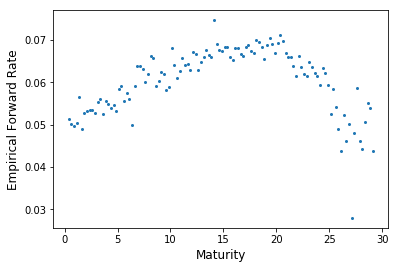

In [11]:
import pandas as pd

forratedat = pd.read_csv(
"http://www.stat.cmu.edu/~cschafer/MSCF/forratedat.txt",
    sep=" ")

fig, axs = plt.subplots(1, 1, figsize=[6,4])
axs.plot(forratedat['maturity'],forratedat['emp'],
    marker='.', ms=4, linestyle="none")
axs.set_xlabel("Maturity", size=12)
axs.set_ylabel("Empirical Forward Rate", size=12)
plt.show()

We will consider polynomial models of the form
\begin{equation*}
   Y_i = \sum_{j=0}^p \beta_j T_i^j + \epsilon_i
\end{equation*}
with a goal of finding the best subset of the $p$ polynomial terms to include
in the model. (As is usually the case, 
we do not consider removing the intercept $\beta_0$.)

The "full" model (largest possible model) we'll consider includes up to
the ninth power.

We will **scale** maturity to have mean zero and variance one:

In [12]:
forratedat['maturity'] = (forratedat['maturity'] - \
        forratedat['maturity'].mean()) / \
        (forratedat['maturity'].std())

**Exercise:** Why is scaling the predictor a good idea in this case?

\answerlines{7}

\newpage 

Now, we can fit the full model:

In [13]:
forratedat['maturity2'] = forratedat['maturity'] ** 2
forratedat['maturity3'] = forratedat['maturity'] ** 3
forratedat['maturity4'] = forratedat['maturity'] ** 4
forratedat['maturity5'] = forratedat['maturity'] ** 5
forratedat['maturity6'] = forratedat['maturity'] ** 6
forratedat['maturity7'] = forratedat['maturity'] ** 7
forratedat['maturity8'] = forratedat['maturity'] ** 8
forratedat['maturity9'] = forratedat['maturity'] ** 9

import statsmodels.formula.api as smf

X_with_ones = sm.add_constant(
    forratedat.drop('emp', axis=1))
fullmod = smf.OLS(endog=forratedat['emp'],
    exog=X_with_ones).fit()

/Users/chadschafer/anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:2389: FutureWarning: Method .ptp is deprecated and will be removed in a future version. Use numpy.ptp instead.
  return ptp(axis=axis, out=out, **kwargs)


\newpage

**Exercise:** Inspect `fullmod.summary()` and comment on the parameter estimates. Do you think that this model actually needs this many terms, or are we at risk of overfitting?

\answerlines{6}

\newpage

## Exhaustive Search {-}

In cases where the number of predictors is small, an exhaustive search
over all possible models is possible.

**Exercise:** If a model has $p$ candidate predictors, how many models are compared in the exhaustive search?

\answerlines{1}

In [14]:
import itertools
from tqdm import tnrange, tqdm_notebook

X = forratedat.drop('emp', axis=1)
df = {}

for k in tnrange(1, len(X.columns)+1):
    for combo in \
      itertools.combinations(X.columns, k):
        X_with_ones = sm.add_constant(X[list(combo)])
        model = smf.OLS(endog=forratedat['emp'],
            exog=X_with_ones).fit()
        df[str(combo)] = model.aic
        
df = pd.Series(df)

**Exercise:** Parse the Python code in the previous example.

\answerlines{20}

\newpage

If you look at `df.idxmin()`, we see that the AIC-optimal model is
\begin{equation*}
   Y_i = \beta_0 + \beta_1 T_i + \beta_4 T_i^4 + \beta_5 T_i^5 + \beta_6 T_i^6 + \beta_7 T_i^7 + \epsilon_i
\end{equation*}
Let's fit that model.

**Exercise:** Which fit has a larger value of $R^2$, the AIC-optimal model, or the full model?

\answerlines{3}

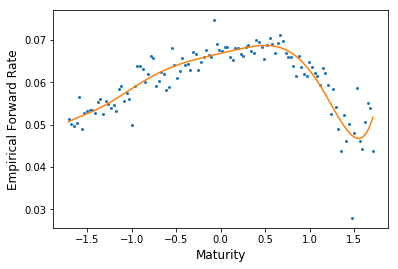

In [15]:
X_with_ones = \
   sm.add_constant(X.iloc[:,[0,3,4,5,6]])

AICoptmodel = smf.OLS(\
    endog=forratedat['emp'],
    exog=X_with_ones).fit()

fig, axs = plt.subplots(1, 1, figsize=[6,4])
axs.plot(forratedat['maturity'],forratedat['emp'],
    marker='.', ms=4, linestyle="none")
axs.set_xlabel("Maturity", size=12)
axs.set_ylabel("Empirical Forward Rate", size=12)
axs.plot(forratedat['maturity'], 
    AICoptmodel.fittedvalues,ms=10)
plt.show()

**Exercise:** Comment on the quality of the fit of the model.

\answerlines{5}

\newpage

## Stepwise Regression {-}

An exhaustive search is not feasible when there is a large number of
predictors.

A classic strategy for dealing with the large number of possible models
is to use a **stepwise variable selection** procedure.

With this method, one (typically) starts with the largest model under consideration,
and then takes a sequence of **steps**: At each step one predictor is 
either **added** or **dropped**, depending on if a **forward** or **backward** selection
procedure is used, respecitvely.

The decision for which step to take (i.e., which covariate to add or
drop) is based on AIC: You take the step which reduces AIC the most.

Once AIC no longer changes, the process stops, and you have your final
model.

This algorithm is far from perfect, but is useful in the appropriate 
situations.

\newpage

In [16]:
features_chosen = []
remaining_features = list(X.columns.values)
best_AIC = np.inf

for i in range(1, k+1):
    add_feature = False
    
    for combo in itertools.combinations\
      (remaining_features, 1):
        X_with_ones = sm.add_constant(\
      X[list(combo) + features_chosen])
        model = smf.OLS(endog=forratedat\
      ['emp'], exog=X_with_ones).fit()
        this_AIC = model.aic

        if this_AIC < best_AIC:
            add_feature = True
            best_AIC = this_AIC
            best_feature = combo[0]
    
    if add_feature:
        features_chosen.append(best_feature)
        remaining_features.remove(best_feature)

\newpage

The resulting model fit is

\begin{equation*}
   Y_i = \beta_0 + \beta_1 T_i + \beta_2 T_i^2 + \beta_4 T_i^4 + \beta_5 T_i^5 + \beta_7 T_i^7 + \beta_8 T_i^8 + \epsilon_i
\end{equation*}

We can see that this is quite similar to the model fit before, although not identical.

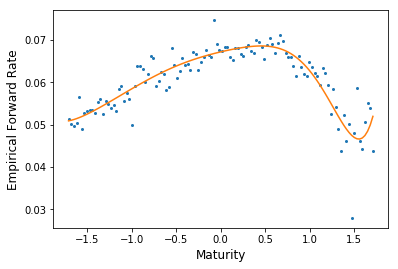

In [17]:
X_with_ones = \
   sm.add_constant(X.iloc[:,[0,1,3,4,6,7]])

FSWoptmodel = smf.OLS(\
    endog=forratedat['emp'],
    exog=X_with_ones).fit()

fig, axs = plt.subplots(1, 1, figsize=[6,4])
axs.plot(forratedat['maturity'],forratedat['emp'],
    marker='.', ms=4, linestyle="none")
axs.set_xlabel("Maturity", size=12)
axs.set_ylabel("Empirical Forward Rate", size=12)
axs.plot(forratedat['maturity'], 
    FSWoptmodel.fittedvalues,ms=10)
plt.show()

\newpage

## Cross Validation {-}

We've discussed the use of AIC for the purpose of
**model selection**, i.e.~the process of determining which
covariates should be included in the model.

An important alternative is **leave-one-out cross validation**.

In this approach, one imagines refitting the model $n$ times,
each time excluding one of the $n$ observations. 

At iteration $i$, observation $i$ is excluded. The fitted model
is then used to predict the response for this observation. 
Call this $\widehat y_{(-i)}$.

Finally, we calculate the quantity
\begin{equation*}
   {\rm PRESS} = \sum_{i=1}^n \left(y_i -\widehat y_{(-i)}\right)^2
\end{equation*}
where **PRESS** stands for **Prediction Error Sum of Squares**.

\newpage

The motivation for this is as follows: Once observation $i$ is removed
from the fit, we have removed the **influence** that this observation
has on the parameter estimates.

Now, we can think of observation $i$ as being a "new" observation,
and we can ask: "How well does the model, containing only these covariates,
predict the response for this case?" 

The quantity $(y_i - \widehat y_{(-i)})^2$ quantifies the amount of error in this
prediction.

**Exercise:** Which is larger: PRESS or RSS?

\answerlines{9}

\newpage

Fortunately, it is not actually necessary to fit $n$ models in order 
calculate PRESS.

The remarkable result is as follows:

Let ${\bf Y}$ be a vector consisting of the $n$ responses, and
let $\widehat {\bf Y}$ be a vector consisting of the $n$ fitted
values (from the full model).

If it is the case that $\widehat {\bf Y} = {\bf H} {\bf Y}$, then 
\begin{equation*}
   y_i - \widehat y_{(-i)} = \frac{\widehat \epsilon_i}{1-h_{ii}} 
\end{equation*}
where $h_{ii}$ is the $i^{th}$ diagonal element of ${\bf H}$.

In the case of linear regression, it is the case that
\begin{equation*}
   {\bf H} = {\bf X} \left({\bf X}^T{\bf X}\right)^{-1} {\bf X}^T
\end{equation*}
where ${\bf X}$ whose columns hold the values of the predictors.
See Ruppert and Matteson for the details.

This matrix ${\bf H}$ is previously mentioned **hat matrix**.

The diagonal elements $h_{ii}$ are called the **leverages**.

\newpage

The leverages can be found in Python using the following.

In [18]:
import statsmodels.stats.outliers_influence \
   as outliers_influence

levs = outliers_influence.OLSInfluence(fullmod)\
   .hat_matrix_diag

and then PRESS can be calculated as

In [19]:
PRESS = ((fullmod.resid / (1 - levs))**2).sum()
print(PRESS)

0.0019740282761601747


\newpage

The following code performs an exhaustive search for the optimal model when using PRESS.

In [20]:
X = forratedat.drop('emp', axis=1)
df2 = {}

for k in tnrange(1, len(X.columns)+1):
    for combo in \
      itertools.combinations(X.columns, k):
        X_with_ones = \
           sm.add_constant(X[list(combo)])
        model = smf.OLS(endog=forratedat['emp'],
           exog=X_with_ones).fit()
        levs = outliers_influence.\
           OLSInfluence(model).hat_matrix_diag
        df2[str(combo)] = \
           ((model.resid / (1 - levs))**2).sum()
        
df2 = pd.Series(df2)

\newpage

The resulting model fit is
\begin{equation*}
   Y_i = \beta_0 + \beta_1 T_i + \beta_3 T_i^3 + \beta_4 T_i^4 + \beta_6 T_i^6 + \beta_7 T_i^7 + \epsilon_i
\end{equation*}
This is, again, a sightly different model, but it yields almost identical predictions for the response.

\newpage

## AIC versus PRESS {-}

AIC and PRESS will often give similar, if not the same, result for the
model choice.

There are a couple main reasons to prefer
PRESS to AIC: First, the quantity being estimated is by PRESS
is a very natural measure of prediction performance. Second, the
theory behind AIC is based on the assumption that the disributional
assumption for the response is correct.

A main reason to choose AIC over PRESS is that AIC is more
stable. 
The estimate
that PRESS provides of the expected prediction error is subject
to large variance. Hence, PRESS may
not perform well for small to moderate sample sizes.

Although PRESS is simple to calculate in the case of linear
regression, this will not always be the case. In general,
AIC will be easier to calculate than PRESS.

As is often the case, our past experience will often guide our
choice of criterion.

\newpage

## Robust Regression {-}

In the least squares approach to regression, we seek the
$\boldsymbol{\beta}$ that minimizes the residual sum of squares
\begin{equation*}
   \sum_{i=1}^n \left(y_i - {\bf x}_i^T\!\boldsymbol{\beta}\right)^2.
\end{equation*}

Of course, this is equivalent to minimizing
\begin{equation*}
   \frac{1}{\sigma^2} \sum_{i=1}^n \left(y_i - {\bf x}_i^T\!\boldsymbol{\beta}\right)^2
   =
   \sum_{i=1}^n \left(\frac{y_i - {\bf x}_i^T\!\boldsymbol{\beta}}{\sigma}\right)^{\!2}
   = 
   \sum_{i=1}^n \rho\!\left(\frac{y_i - {\bf x}_i^T\!\boldsymbol{\beta}}{\sigma}\right)
\end{equation*}
where $\rho(x) = x^2$.

The general concern with $\rho(x) = x^2$ is that it may place too much weight
on extreme observations: Think about how quickly the function $x^2$ increases
as $|x|$ increases.

The choice $\rho(x) = x^2$ may be optimal when the errors are normal, but
it is not very **robust** to deviations from this assumption.

If we generated errors from the $t$ distribution with four degrees of freedom,
for instance, we are likely to see a few extreme errors. These observations
would have a large influence on the fit of the model, if we proceeded with
$\rho(x) = x^2$.

\newpage

There are many possible choices for $\rho$, but here we will focus on
a popular one, the **Huber loss function**, which is defined as
\begin{equation*}
   \rho_{\mbox{\tiny Hub}}(x) = \left\{
   \begin{array}{ll}
   x^2 & \mbox{if $|x| < k$} \\
   k(2|x| -k) & \mbox{otherwise} \\
   \end{array}
   \right.
\end{equation*}
where $k >0$ is set by the user. For technical reasons, the
default choice is $k = 1.345$.

The figure above compares squared error loss with the Huber
loss function.

![Comparison of Loss Functions.](Robust/rhos.png)

\newpage

**Exercise:** What is the effect of varying $k$ in
the Huber loss function?

\answerlines{18}

\newpage

**Example.** Here the truth is that $\beta_0 = 1$ and $\beta_1 = 10$.
The sample size is $n=100$. The error has the $t$ distribution with
a single degree of freedom, so there is great potential for extreme
observations.

The figure above shows two simulated
data sets under these conditions, each with the true line (solid),
the regression line estimated using least squares (dashed), and
the regression line estimated using the Huber loss (dashed-dot).

![The effect of outliers on the fit.](Robust/robustsims.png)

It is clear that in both instances that the Huber loss function
effectively downweights the extreme observations, and, as a result,
results in a closer approximation to the truth.

These examples are, admittedly, chosen to be extreme to illustrate
the point. Nevertheless, robust regression is useful in situations
where it is suspected that the error distribution is not normal,
and there is concern over extreme observations.

\newpage

Robust regression is implemented in Python using `RLM` from
`statsmodels`.

The argument `M` sets the loss function. (This falls into the general class
of problems called **M-estimation**.)
The default setting is `M=sm.robust.norms.HuberT`,
which uses the Huber loss function
with $k=1.345$.

In [21]:
ff3modPNCrob = sm.RLM.from_formula\
  (formula="PNCexret ~ MktRF + SMB + HML",
     data=ffhold).fit()

**Exercise:** Compare the results of this fit with least squares. Have the coefficients changed much?

\answerlines{10}